# **Analyze Financial Data with Python Capstone**

##### By Faatimah Majothi

### Project Goals

The purpose of this capstone project is to practice accessing and downloading financial data, calculating financial statistics to understand the individual performance of an asset and how groups of assets are related, and how to allocate investments across assets for optimal performance.
In this project, I will create a presentation that showcases a portfolio of stocks that I recommend my client invest in, and provide the weights at which they should invest in each stock depending on their risk preference.

**Note: All information in this project is for research purposes only, and is not recommended investment advice. Investing is at your own risk.**

## Stocks Overview

The following stocks will be analysed in this project:

|**NASDAQ**   |**STOCK COMPANY**                |
|-------------|---------------------------------|
|AXIA         |AXIA Energia SA                  |
|BEPC         |Brookfield Renewable Corporation |
|VGAS         |Verde Clean Fuels, Inc.          |
|CWEN         |Clearway Energy, Inc.            |
|RNW          |ReNew Energy Global Plc          |
|FLNC         |Fluence Energy, Inc.             |
|AGIG         |Abundia Global Impact Group Inc. |

More information on each stock is provided below.
- **AXIA Energia SA**: This Brazil-based company generates electricity through hydroelectric, thermoelectric, nuclear, wind, and solar plants.
- **Brookfield Renewable Corporation**: The company’s portfolio of renewable power and sustainable solution assets consists of hydroelectric, wind, utility-scale solar, distributed generation, pumped storage, carbon capture and storage, cogeneration, biomass, and eFuels.
- **Verde Clean Fuels, Inc.**: A clean fuels company that focuses on the deployment of liquid fuels processing technology through development of commercial production plants in the US.
- **Clearway Energy, Inc.**: Operates through Flexible Generation and Renewables & Storage segments in the US. The company’s portfolio is made up of wind, solar, and battery energy storage systems; and  dispatchable combustion-based power generation assets included in the Flexible Generation segment that provide critical grid reliability services.
- **ReNew Energy Global Plc**: This company, together with its subsidiaries, engages in the generation of power through non-conventional and renewable energy sources in India. It operates through five segments: Wind Power, Solar Power, Hydro Power, Transmission Line, and Manufacturing segments.
- **Fluence Energy, Inc.**: Through its subsidiaries, the company provides energy storage and optimization software for renewables and storage applications in the Americas, the Asia Pacific, Europe, the Middle East, and Africa. It sells energy storage products with integrated hardware, software, and digital intelligence.
- **Abundia Global Impact Group Inc.**: This independent renewable and clean energy project developer, power producer, and asset operator company focuses on solar photovoltaic power generation projects, battery energy storage systems, and EV-charging projects, grid connected solar PV electricity power plants and battery energy storage system.

All API data and company information is sourced from [stockanalysis.com](https://stockanalysis.com/stocks/industry/utilities-renewable/).

## Inititialising Libraries and Data

In [59]:
# Importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import yfinance as yf
import cvxopt as opt
from cvxopt import blas, solvers
import matplotlib.pyplot as plt

In [112]:
# Initialising data

symbols = ['AXIA', 'BEPC', 'VGAS', 'CWEN', 'RNW', 'FLNC', 'AGIG']
start_date = datetime(2024, 1, 1)
stock_data = yf.download(symbols, start=start_date, auto_adjust = True) 

# Select closing price data

closing_price = stock_data['Close']
closing_price.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AGIG,AXIA,BEPC,CWEN,FLNC,RNW,VGAS
Date,,,,,,,
2024-01-02,17.900000,7.481393,26.105389,23.837700,23.850000,7.55,2.31
2024-01-03,18.400000,7.463770,26.402554,23.530855,22.480000,7.58,2.32
2024-01-04,18.000000,7.402085,26.249468,23.522087,21.879999,7.52,2.39
2024-01-05,17.500000,7.472581,26.690712,23.539619,21.500000,7.51,2.31
2024-01-08,16.700001,7.446145,27.546183,23.890305,21.990000,7.52,2.31


### Adjusted Closing Price Over Time

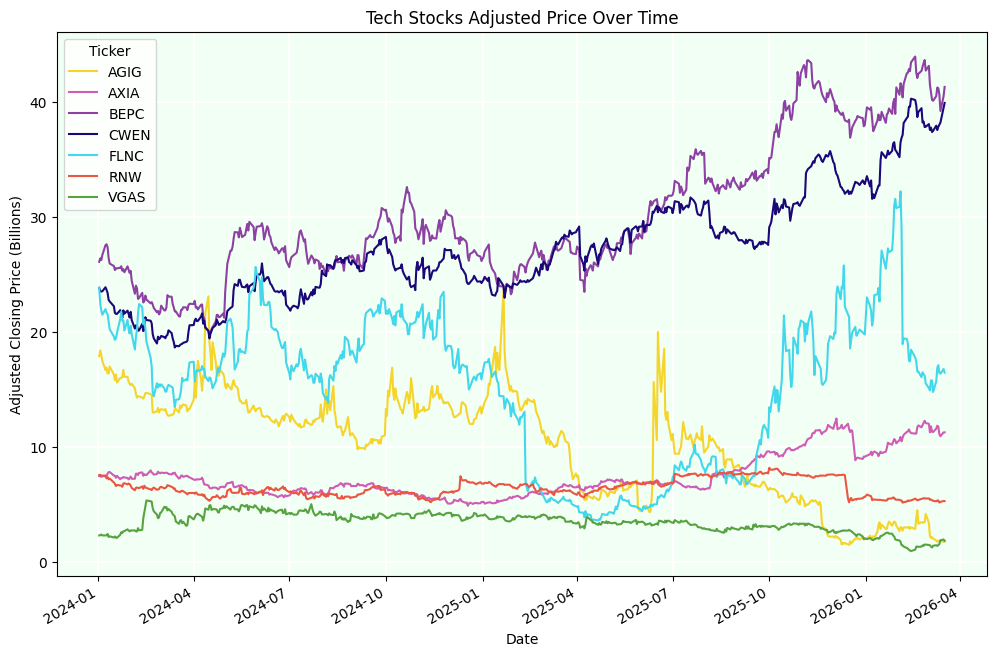

In [106]:
# Setting colors for each stock

stock_cpalette = {
    'AXIA': '#CF5DB5',
    'BEPC': '#8C41A3', 
    'VGAS': '#58A341', 
    'CWEN': '#1A0878', 
    'RNW': '#EB5642', 
    'FLNC': '#42D7EB',
    'AGIG': '#F5D52C'   
}
palette = sns.color_palette([stock_cpalette[s] for s in symbols])
sns.set_palette(palette)

# Plotting the adjusted closing price over time

closing_price.plot(figsize=(12,8), color=stock_cpalette)
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price (Billions)')
plt.title('Tech Stocks Adjusted Price Over Time')
plt.grid(which='both', axis='both', color='white', linewidth=1.5)
plt.gca().set_facecolor('#F2FFF4')
plt.show()
plt.close()

Brookfield Renewable Corporation (**`BEPC`**) and Clearway Energy, Inc. (**`CWEN`**) have both seen a **`rise`** in stock prices over the last two years. Fluence Energy, Inc. (**`FLNC`**) stock closing prices **rose steeply** in the beginning of 2026 before **plummeting** around February. Abundia Global Impact Group Inc. (**`AGIG`**) in particular has seen a **decline** in stock closing prices over the last two years, rising sharply around June 2025 after a steep decline around .

### Daily Simple Rate of Return Over Time

In [110]:
# Calculating the simple daily rate of return (RoR)

stock_data_daily_returns = stock_data['Close'].pct_change()
stock_data_daily_returns.head()

Ticker,AGIG,AXIA,BEPC,CWEN,FLNC,RNW,VGAS
Date,,,,,,,
2024-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03,0.027933,-0.002356,0.011383,-0.012872,-0.057442,0.003973,0.004329
2024-01-04,-0.021739,-0.008265,-0.005798,-0.000373,-0.026690,-0.007916,0.030172
2024-01-05,-0.027778,0.009524,0.016810,0.000745,-0.017367,-0.001330,-0.033473
2024-01-08,-0.045714,-0.003538,0.032051,0.014898,0.022791,0.001332,0.000000


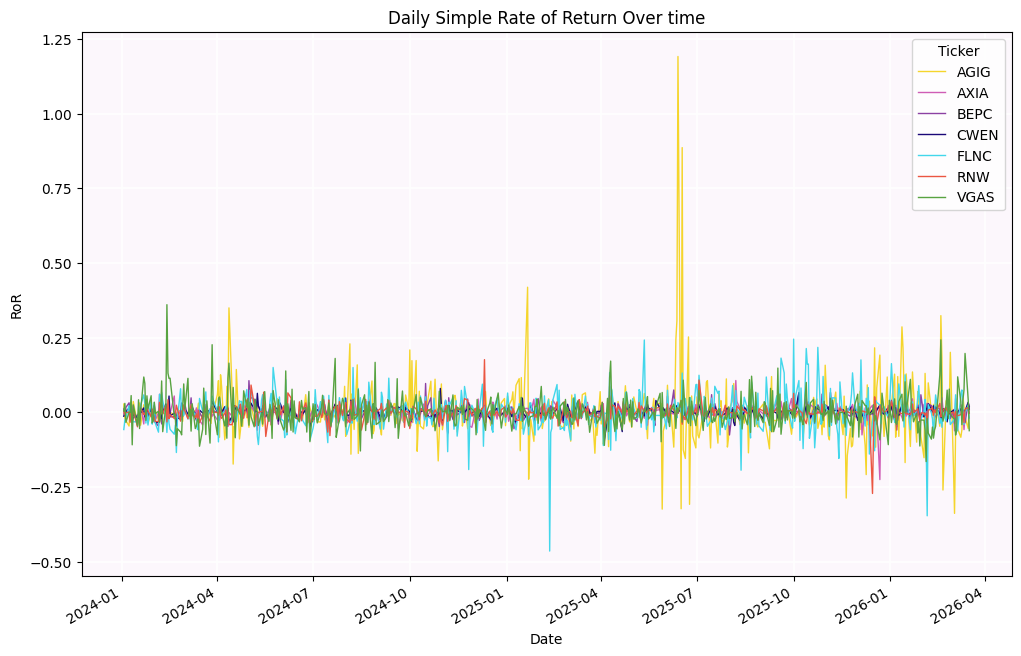

In [111]:
# Plot simple daily RoR

stock_data_daily_returns.plot(figsize=(12,8), linewidth=1, color=stock_cpalette)
plt.xlabel("Date")
plt.ylabel("RoR")
plt.title("Daily Simple Rate of Return Over time")
plt.grid(which='both', axis='both', color='white', linewidth=1.25)
plt.gca().set_facecolor('#FCF7FC') 
plt.show()

At first glance, **`AGIG`** shows the **largest swings** in daily rate of return, indicating that it is the most volatile and risky stock. Around February 2025, **`FLNC`** experienced the **largest single-day loss** on the graph, with a daily rate of return close to -0.5. To get a clearer look at each stock, the daily simple RoR over time for each is plotted seperately.

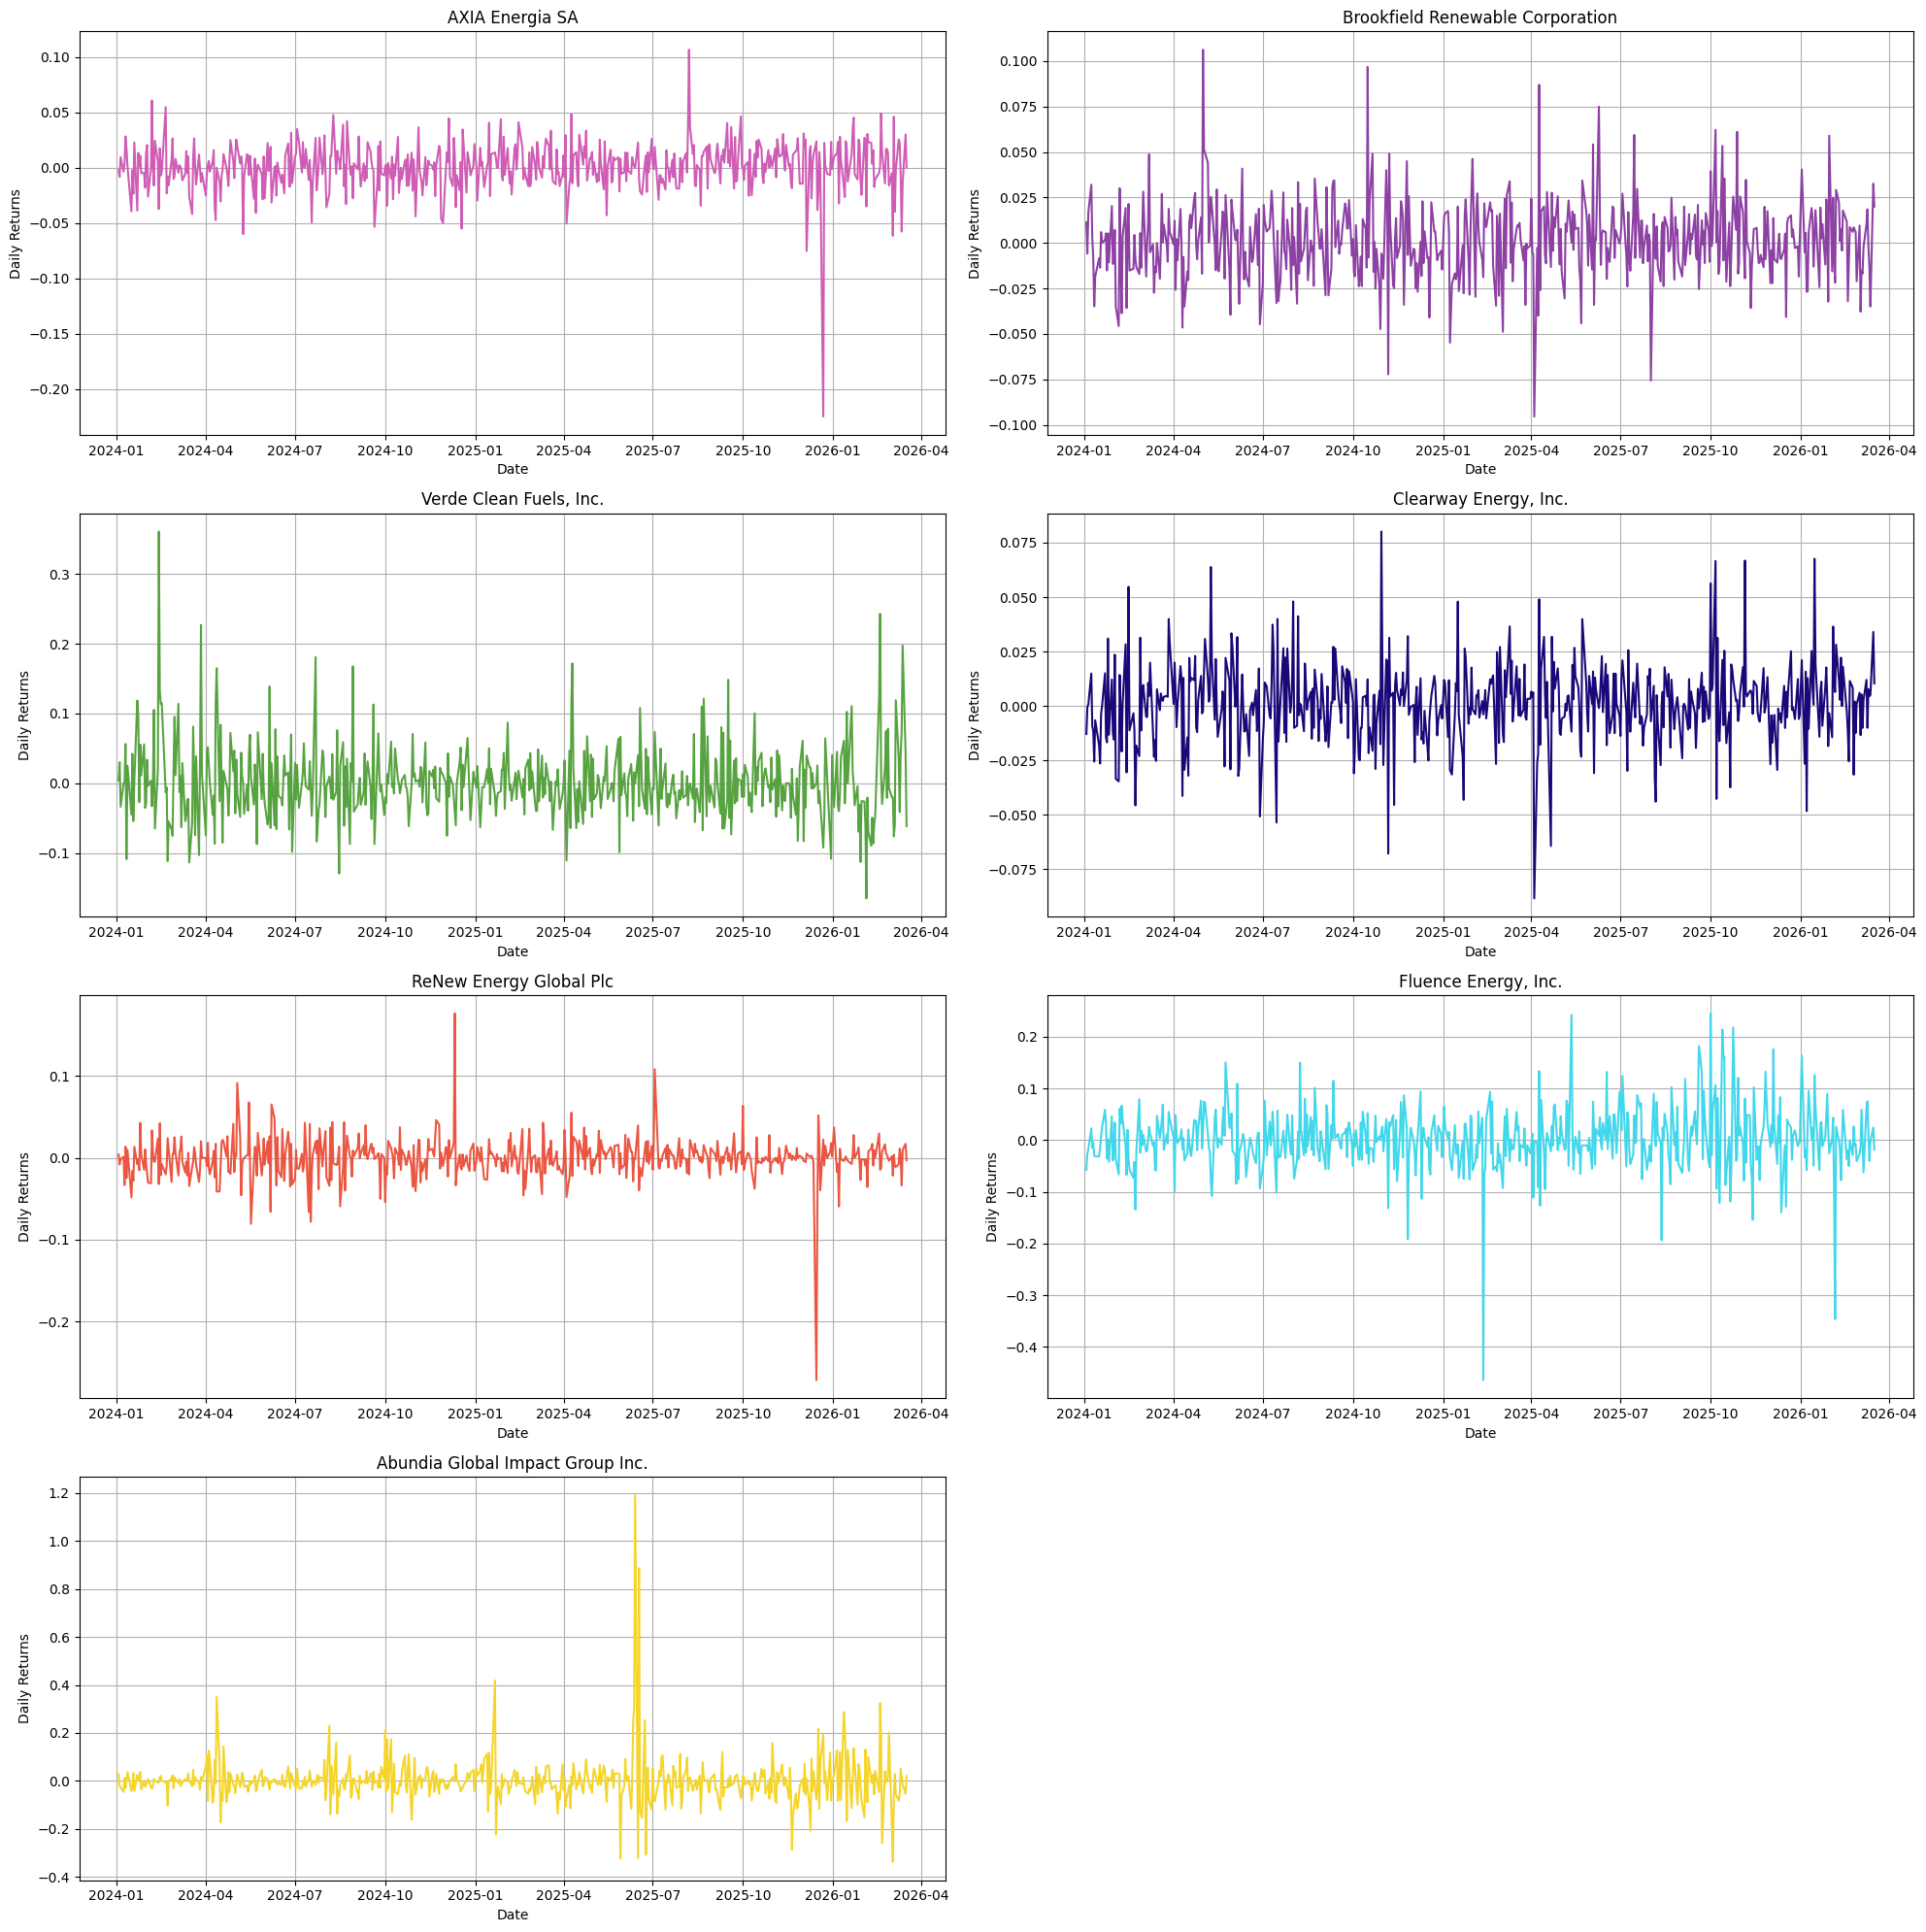

In [114]:
# Plot subplots

fig = plt.figure(figsize=(20,20))

ax1 = fig.add_subplot(421)
ax2 = fig.add_subplot(422)
ax3 = fig.add_subplot(423)
ax4 = fig.add_subplot(424)
ax5 = fig.add_subplot(425)
ax6 = fig.add_subplot(426)
ax7 = fig.add_subplot(427)

ax1.plot(stock_data_daily_returns['AXIA'], color=stock_cpalette['AXIA'])
ax1.set_title('AXIA Energia SA')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Returns')
ax1.grid(True)

ax2.plot(stock_data_daily_returns['BEPC'], color=stock_cpalette['BEPC'])
ax2.set_title('Brookfield Renewable Corporation')
ax2.set_xlabel('Date')
ax2.set_ylabel('Daily Returns')
ax2.grid(True)

ax3.plot(stock_data_daily_returns['VGAS'], color=stock_cpalette['VGAS'])
ax3.set_title('Verde Clean Fuels, Inc.')
ax3.set_xlabel('Date')
ax3.set_ylabel('Daily Returns')
ax3.grid(True)

ax4.plot(stock_data_daily_returns['CWEN'], color=stock_cpalette['CWEN'])
ax4.set_title('Clearway Energy, Inc.')
ax4.set_xlabel('Date')
ax4.set_ylabel('Daily Returns')
ax4.grid(True)

ax5.plot(stock_data_daily_returns['RNW'], color=stock_cpalette['RNW'])
ax5.set_title('ReNew Energy Global Plc')
ax5.set_xlabel('Date')
ax5.set_ylabel('Daily Returns')
ax5.grid(True)

ax6.plot(stock_data_daily_returns['FLNC'], color=stock_cpalette['FLNC'])
ax6.set_title('Fluence Energy, Inc.')
ax6.set_xlabel('Date')
ax6.set_ylabel('Daily Returns')
ax6.grid(True)

ax7.plot(stock_data_daily_returns['AGIG'], color=stock_cpalette['AGIG'])
ax7.set_title('Abundia Global Impact Group Inc.')
ax7.set_xlabel('Date')
ax7.set_ylabel('Daily Returns')
ax7.grid(True)


plt.tight_layout()
plt.show()
plt.close()

ReNew Energy Global Plc (**`RNW`**) and AXIA Energia SA (**`AXIA`**) both have a **large single-day loss** in December 2025, which **may indicate** some kind of **correlation** between the two stocks. The three **most volatile stocks** in terms of daily RoR are Abundia Global Impact Group Inc. (**`AGIG`**), Verde Clean Fuels, Inc. (**`VGAS`**) and Fluence Energy, Inc. (**`FLNC`**), in that order.

### Mean Daily Rate of Return

In [116]:
# Calculate average RoR 

avg_returns = stock_data_daily_returns.mean()

# Create a dataframe to make plotting easier

avg_returns_df = average_returns.reset_index()
avg_returns_df.columns = ['Stock', 'Average Return']

avg_returns_df

,Stock,Average Return
0,AGIG,0.000042
1,AXIA,0.000997
2,BEPC,0.001067
3,CWEN,0.001107
4,FLNC,0.001293
5,RNW,-0.000316
6,VGAS,0.000933


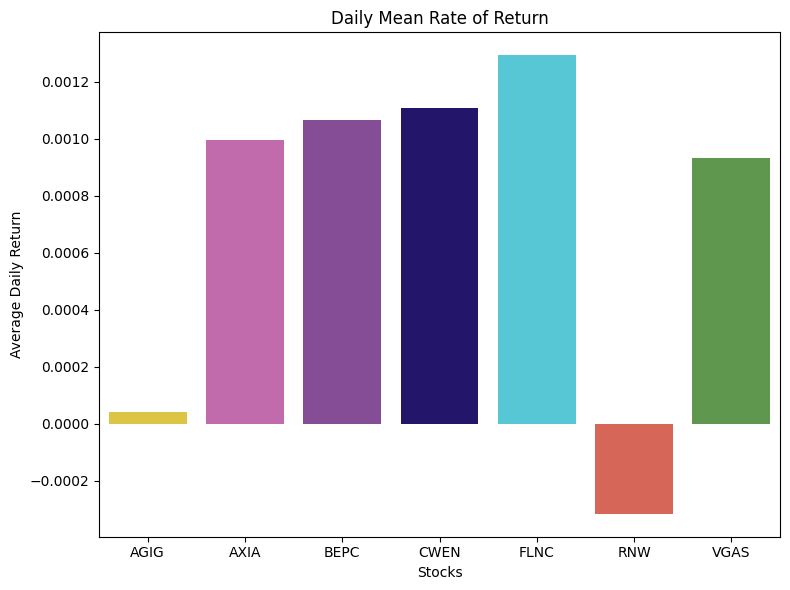

In [123]:
# Plot a bar chart of the average RoRs

plt.figure(figsize=(8,6))
sns.barplot(x='Stock', y='Average Return', hue = 'Stock', data=avg_returns_df, palette=stock_cpalette)
plt.xlabel('Stocks')
plt.ylabel('Average Daily Return')
plt.title('Daily Mean Rate of Return')

plt.tight_layout()
plt.show()
plt.close()

Abundia Global Impact Group Inc. (**`AGIG`**) has the **lowest** average daily rate of return (**`RoR`**) among the stocks, while ReNew Energy Global Plc (**`RNW`**) has a **negative** average daily RoR. This suggests these two stocks have **underperformed** over the last two years. Fluence Energy, Inc. (**`FLNC`**) has the **highest** average daily RoR, making it the **top performer** out of the stocks **based on recent daily returns**.